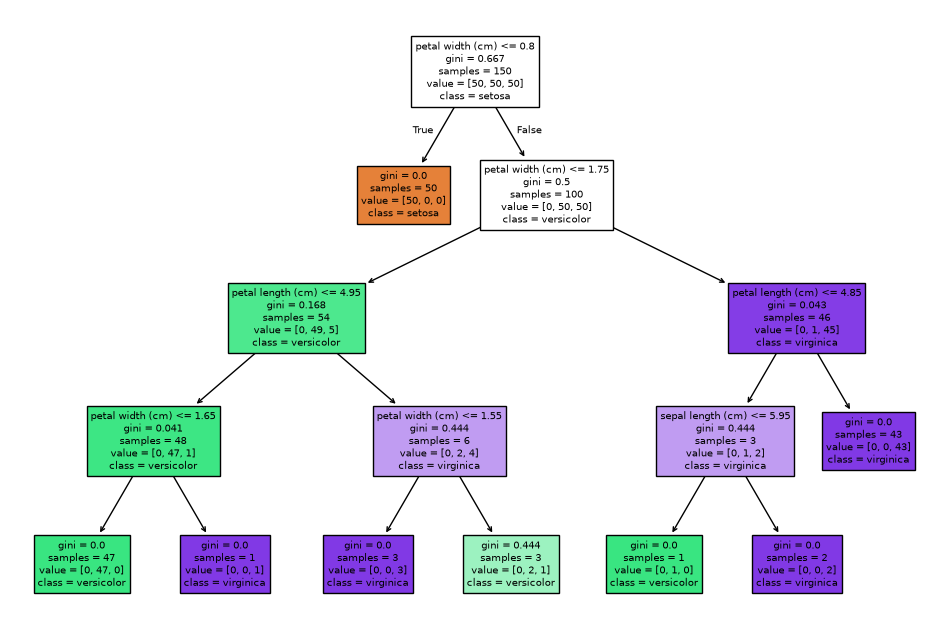

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 데이터 로드 및 모델 학습
iris = load_iris()
X, y = iris.data, iris.target
model = DecisionTreeClassifier(max_depth=4)
model.fit(X, y)

# 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

In [ ]:
from collections import Counter

# 어떤 리프 노드에 도달한 샘플들의 실제 클래스
leaf_samples = ['A', 'A', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'A']  # 8 : 2

counts = Counter(leaf_samples)  # {'A' : 8, 'B' : 2}
total = len(leaf_samples)

probs = {cls: cnt / total for cls, cnt in counts.items()}
print(probs)   # 예: {'A': 0.8, 'B': 0.2}

{'A': 0.8, 'B': 0.2}


In [8]:
from collections import Counter

# 지니 불순도 계산

# 한 노드에 있는 샘플들의 클래스
node = ['A', 'A', 'B', 'A', 'B', 'A']  # 4:2

counts = Counter(node)
total = len(node)

gini = 1 - sum((cnt/total)**2 for cnt in counts.values())
print(round(gini, 3))   # 예: 0.444


0.444


In [ ]:
# 엔트로피 공식
import math
from collections import Counter

# 한 노드에 있는 샘플의 클래스 구성
node = ['A', 'A', 'B', 'A', 'B', 'A']  # 4:2

counts = Counter(node)
total = len(node)

entropy = -sum((cnt/total) * math.log2(cnt/total) for cnt in counts.values())
print(round(entropy, 3))   # 예: 0.918

0.918


In [12]:
# 정보이득 계산 
import math
from collections import Counter

def entropy(labels):
    total = len(labels)
    counts = Counter(labels)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())  # 엔트로피 공식에 의한 출력

# 전체 데이터의 클래스
D = ['A', 'A', 'B', 'A', 'B', 'A']   # 엔트로피 계산
H_D = entropy(D)   # 전체 엔트로피

# 속성 A로 분할한 경우
Dv1 = ['A', 'A', 'A']   # 예: feature A = 0 그룹
Dv2 = ['B', 'A', 'B']   # 예: feature A = 1 그룹

H_split = (len(Dv1)/len(D)) * entropy(Dv1) + \
          (len(Dv2)/len(D)) * entropy(Dv2)

IG = H_D - H_split

print("정보 이득:", round(IG, 3))

# 0~1 사이의 값을 가진다.
# 잘 분할이 되었을땐 1, 분할이 안되었을땐 0

정보 이득: 0.459


### **결정 트리에서의 역할**

- 정보 이득은 **결정 트리**에서 데이터를 분할할 속성을 선택하는 기준으로 사용된다.
- 트리의 각 노드에서 가능한 모든 속성에 대해 정보 이득을 계산하고, 가장 높은 정보 이득을 가진 속성을 선택하여 데이터를 분할한다.

In [15]:
# 규제 파라미터 효과 
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 규제 없음 (과적합 가능)
model1 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train, y_train)
print("규제 없음 정확도:", model1.score(X_test, y_test))

# 최대 깊이 제한
model2 = DecisionTreeClassifier(max_depth=2, random_state=42)
model2.fit(X_train, y_train)
print("max_depth=2 정확도:", model2.score(X_test, y_test))
# 최대 깊이 제한
model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X_train, y_train)
print("max_depth=3 정확도:", model2.score(X_test, y_test))
# 최대 깊이 제한
model2 = DecisionTreeClassifier(max_depth=5, random_state=42)
model2.fit(X_train, y_train)
print("max_depth=5 정확도:", model2.score(X_test, y_test))


#규제를 넣으면 정확도가 소폭 줄어들 수도 있는데, 대신 과적합 위험이 감소하고 모델이 더 단순해짐(max_depth 기본값 : None)

규제 없음 정확도: 1.0
max_depth=2 정확도: 0.9777777777777777
max_depth=3 정확도: 1.0
max_depth=5 정확도: 1.0


In [19]:
# 회귀 트리

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import numpy as np

# 회귀용 california housing 데이터 로드
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 규제 없는 회귀 트리
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 첫 번째 테스트 샘플 예측
pred = model.predict([X_test[0]])
print("예측값:", np.round(pred[0], 3))

예측값: 0.414


- 과적합(Overfitting)은 모델이 학습 데이터에 지나치게 맞춰져, 새로운 데이터에 대한 일반화 성능이 떨어지는 문제를 말한다.   
결정 트리의 경우, 트리가 너무 깊어져 학습 데이터의 세부 사항(노이즈까지)을 지나치게 학습하면 과적합이 발생할 수 있다.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 가지치기 없음 (과적합 가능)
model_full = DecisionTreeClassifier(random_state=42)
model_full.fit(X_train, y_train)
print("가지치기 없음:", model_full.score(X_test, y_test))

# 사전 가지치기: 트리 깊이 제한
model_pruned = DecisionTreeClassifier(max_depth=2, random_state=42)
model_pruned.fit(X_train, y_train)
print("max_depth=2 가지치기:", model_pruned.score(X_test, y_test))

model3 = DecisionTreeClassifier(max_depth=3, random_state=42)
model3.fit(X_train, y_train)
print("max_depth=3 정확도:", model2.score(X_test, y_test))
# 최대 깊이 제한
model5 = DecisionTreeClassifier(max_depth=5, random_state=42)
model5.fit(X_train, y_train)
print("max_depth=5 정확도:", model2.score(X_test, y_test))

가지치기 없음: 1.0
max_depth=2 가지치기: 0.9777777777777777
max_depth=3 정확도: 1.0
max_depth=5 정확도: 1.0
